# GO proposals for AGN

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Paths to where data is stored
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir('smbhb')
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'simulations'
gdir = path / 'godata'
fdir = Path('/lhome/nicholas/Nextcloud/latex/plato_go_proposals')
# fdir = path / 'figures'

In [4]:
# Load LOP catalogues for plotting
ds = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')
df = pd.read_feather(idir / 'starcat_PlatoCS_QSO_LOPS2_targets.ftr')

---
## 1. Target list
---

### Initial target list for CfP

In [5]:
# Limited magnitude cut and sort after magnitude
df0 = df[df.Pmag < 17.5].sort_values(by=['Pmag'])

# Convert units [ppm -> ppt]
df0.NSR /= 1e3

# Remove heavily contaminated sources
df0 = df0[df0.SPR < 0.05]

# Show remaining targets
df0 = df0.reset_index(drop=True)
df0

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
0,12,5477304692317531392,96.155124,-63.411827,273.000153,15.573731,-27.017729,15.752692,0.561028,1.6737,...,0.489572,0.195311,NaN,NaN,NaN,NaN,14.0,0.000652,11.274203,1.506352
1,12,4787832939454577536,67.655418,-48.923216,255.789644,15.651070,-42.910615,15.834169,0.576308,NaN,...,1.941430,0.214852,NaN,NaN,NaN,NaN,6.0,0.000054,13.646734,1.644273
2,6,4828236384002699520,57.747604,-52.676254,263.037832,15.658949,-48.152123,15.851448,0.611596,1.8750,...,1.542538,0.402480,NaN,NaN,NaN,NaN,4.0,0.000771,17.738992,2.351849
3,24,2882337747595526528,90.061215,-41.091122,247.628114,15.666400,-26.633623,15.844106,0.556419,1.8918,...,1.034759,0.341419,NaN,NaN,NaN,NaN,8.0,0.022996,11.239457,1.030801
4,12,5284905413180301824,97.943273,-64.437557,274.255541,15.679995,-26.376037,15.838762,0.488517,1.5718,...,0.882349,0.278096,NaN,NaN,NaN,NaN,13.0,0.036189,12.187117,1.501659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,12,5282663886929616256,109.135299,-64.201447,275.203103,17.492547,-21.604331,17.645678,0.468842,0.0004,...,1.557316,0.105745,NaN,NaN,NaN,NaN,17.0,0.000478,13.362746,8.322330
385,6,4868589251015024768,65.491859,-37.225334,239.613960,17.493509,-44.906767,17.674938,0.570124,0.0006,...,1.583688,0.077120,NaN,NaN,NaN,NaN,0.0,0.000000,15.941748,11.681631
386,12,4787986385750175488,69.092051,-48.890972,255.607327,17.494242,-41.975434,17.620417,0.377808,0.9651,...,0.458015,0.050318,NaN,NaN,NaN,NaN,3.0,0.001030,12.799025,7.432101
387,18,4763230885746763776,80.153619,-57.975048,266.436406,17.494605,-34.664079,17.703842,0.676586,0.0095,...,1.539773,0.126740,NaN,NaN,NaN,NaN,5.0,0.000788,12.656421,6.093927


In [6]:
# Create CSV filt for CfP tool
dt0 = pd.DataFrame()
dt0['Target_ID'] = [f'Gaia DR3 {i}' for i in df0.source_gaia_dr3]
dt0['RA'] = df0.ra.to_numpy()
dt0['Dec'] = df0.dec.to_numpy()
dt0['Camera'] = 'normal'
dt0['ProcessingType'] = 'L_FX'
dt0['ObservationLength'] = 720
dt0['StartTime'] = None
dt0['EndTime'] = None

# Save catalogue
dt0.to_csv(gdir / 'source_catalogue_agn_cfp_v0.csv', index=False)
dt0

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime
0,Gaia DR3 5477304692317531392,96.155124,-63.411827,normal,L_FX,720,None,None
1,Gaia DR3 4787832939454577536,67.655418,-48.923216,normal,L_FX,720,None,None
2,Gaia DR3 4828236384002699520,57.747604,-52.676254,normal,L_FX,720,None,None
3,Gaia DR3 2882337747595526528,90.061215,-41.091122,normal,L_FX,720,None,None
4,Gaia DR3 5284905413180301824,97.943273,-64.437557,normal,L_FX,720,None,None
...,...,...,...,...,...,...,...,...
384,Gaia DR3 5282663886929616256,109.135299,-64.201447,normal,L_FX,720,None,None
385,Gaia DR3 4868589251015024768,65.491859,-37.225334,normal,L_FX,720,None,None
386,Gaia DR3 4787986385750175488,69.092051,-48.890972,normal,L_FX,720,None,None
387,Gaia DR3 4763230885746763776,80.153619,-57.975048,normal,L_FX,720,None,None


### Resubmission to CfP tool

In [19]:
# Load duplication report form CfP tool
dt0_dup = pd.read_csv(gdir / 'CfPtools_duplication_report.csv')
dt0_dup

,Target_ID,isPrimeSampleProximityFlag,isP1SampleProximityFlag,isP2SampleProximityFlag,isP4SampleProximityFlag,isP5SampleProximityFlag,isFgPICProximityFlag,isScvPICProximityFlag,isCPICProximityFlag
0,Gaia DR3 5477304692317531392,1,1,1,0,0,0,0,2
1,Gaia DR3 4787832939454577536,0,0,0,0,0,0,0,0
2,Gaia DR3 4828236384002699520,0,0,0,0,0,0,0,0
3,Gaia DR3 2882337747595526528,0,0,0,0,1,0,0,0
4,Gaia DR3 5284905413180301824,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
384,Gaia DR3 5282663886929616256,0,0,0,0,0,0,0,0
385,Gaia DR3 4868589251015024768,0,0,0,0,0,0,0,0
386,Gaia DR3 4787986385750175488,0,0,0,0,0,0,0,0
387,Gaia DR3 4763230885746763776,0,0,0,1,0,0,0,0


In [20]:
dex = []
dx = dt0_dup
for i in range(dx.shape[0]):
    dx0 = dx.iloc[i]
    count  = dx0.isPrimeSampleProximityFlag
    count += dx0.isP1SampleProximityFlag
    count += dx0.isP2SampleProximityFlag
    count += dx0.isP4SampleProximityFlag
    count += dx0.isP5SampleProximityFlag
    count += dx0.isFgPICProximityFlag
    count += dx0.isScvPICProximityFlag
    count += dx0.isCPICProximityFlag
    if count > 0:
        dex.append(i)
dex = np.array(dex)

In [21]:
# Forbidden targets 
dt0.iloc[dex]

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime
0,Gaia DR3 5477304692317531392,96.155124,-63.411827,normal,L_FX,720,None,None
3,Gaia DR3 2882337747595526528,90.061215,-41.091122,normal,L_FX,720,None,None
6,Gaia DR3 4841167396659799808,63.810269,-40.394754,normal,L_FX,720,None,None
9,Gaia DR3 4665633973057748096,73.566465,-61.274044,normal,L_FX,720,None,None
10,Gaia DR3 2890998291450368896,90.809341,-31.179016,normal,L_FX,720,None,None
...,...,...,...,...,...,...,...,...
358,Gaia DR3 5492706754280919808,115.444355,-52.571097,normal,L_FX,720,None,None
362,Gaia DR3 4782012739076206208,63.138437,-51.358435,normal,L_FX,720,None,None
368,Gaia DR3 2883825554329811072,88.058296,-38.475649,normal,L_FX,720,None,None
387,Gaia DR3 4763230885746763776,80.153619,-57.975048,normal,L_FX,720,None,None


<IPython.core.display.Javascript object>


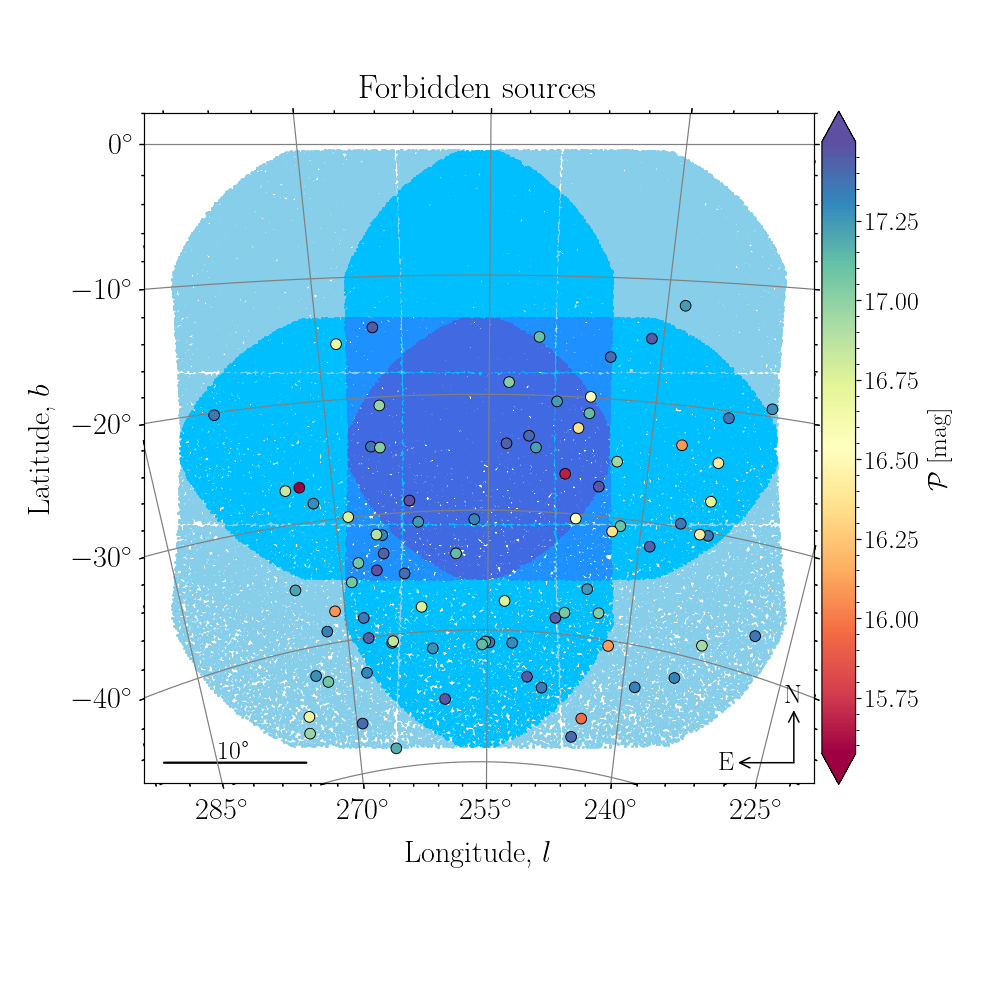

In [22]:
# Plot forbidden targets in LOPS2 
dx = df0.iloc[dex].sort_values(by='Pmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, 
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.6, 
    figsize=(9,9), title='Forbidden sources'
);

In [24]:
# We can upgrade the processing type if not a Prime sample star
# Gaia DR3 5477304692317531392 (ncam=12, Gmag=15.752692) is near a cPIC star
# Gaia DR3 2882337747595526528 (ncam=24, Gmag=15.844106) is near a tPIC star
dx.sort_values(by='Pmag', ascending=True)

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
0,12,5477304692317531392,96.155124,-63.411827,273.000153,15.573731,-27.017729,15.752692,0.561028,1.6737,...,0.489572,0.195311,NaN,NaN,NaN,NaN,14.0,0.000652,11.274203,1.506352
3,24,2882337747595526528,90.061215,-41.091122,247.628114,15.666400,-26.633623,15.844106,0.556419,1.8918,...,1.034759,0.341419,NaN,NaN,NaN,NaN,8.0,0.022996,11.239457,1.030801
6,6,4841167396659799808,63.810269,-40.394754,244.116036,15.952432,-46.262439,16.152750,0.641597,1.7342,...,1.389936,0.345380,NaN,NaN,NaN,NaN,3.0,0.004589,16.063344,2.906918
9,6,4665633973057748096,73.566465,-61.274044,271.024837,16.076538,-37.528174,16.173004,0.282550,1.1903,...,0.535312,0.145575,NaN,NaN,NaN,NaN,5.0,0.047552,9.117055,2.660859
10,12,2890998291450368896,90.809341,-31.179016,237.318857,16.086751,-23.267940,16.227919,0.427847,1.4959,...,0.690946,0.156463,NaN,NaN,NaN,NaN,12.0,0.001382,12.534868,2.501974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,18,5492706754280919808,115.444355,-52.571097,265.219380,17.464544,-14.137106,17.679714,0.700338,0.0038,...,0.530707,0.103280,NaN,NaN,NaN,NaN,24.0,0.031736,12.737390,3.999322
362,12,4782012739076206208,63.138437,-51.358435,259.827309,17.467707,-45.341301,17.632505,0.509829,0.0016,...,1.271823,0.095700,NaN,NaN,NaN,NaN,3.0,0.000596,16.226078,7.803198
368,24,2883825554329811072,88.058296,-38.475649,244.361037,17.473200,-27.496857,17.665527,0.610947,0.0019,...,2.113418,0.125080,NaN,NaN,NaN,NaN,7.0,0.001630,11.023090,5.861343
387,18,4763230885746763776,80.153619,-57.975048,266.436406,17.494605,-34.664079,17.703842,0.676586,0.0095,...,1.539773,0.126740,NaN,NaN,NaN,NaN,5.0,0.000788,12.656421,6.093927


In [11]:
# Save catalogue with forbidden targets removed
dt1 = dt0.drop(dex).reset_index(drop=True)
df1 = df0.drop(dex).reset_index(drop=True)

In [12]:
# Save catalogue with forbidden targets removed
dt1.to_csv(gdir / 'source_catalogue_agn_cfp_v1.csv', index=False)

### Check of angular size

In [13]:
# Load duplication report form CfP tool
dt2 = pd.read_csv(gdir / 'source_catalogue_agn_cfp_v1_extra.csv')
dt2

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime,Simbad,Object,SizeDSS
0,Gaia DR3 4787832939454577536,67.655418,-48.923216,normal,L_FX,720,NaN,NaN,QSO J0430-4855,Quasar,12.0
1,Gaia DR3 4828236384002699520,57.747604,-52.676254,normal,L_FX,720,NaN,NaN,[VV96] J035059.3-524035,Quasar,10.0
2,Gaia DR3 5284905413180301824,97.943273,-64.437557,normal,L_FX,720,NaN,NaN,6dFGS gJ063146.4-642615,Galaxy,10.0
3,Gaia DR3 5279968331097175808,98.290282,-68.575052,normal,L_FX,720,NaN,NaN,2MASS J06330967-6834302,BL Lac,8.0
4,Gaia DR3 4664566278549403392,75.710963,-62.461275,normal,L_FX,720,NaN,NaN,EC 05023-6231,AGN,12.0
...,...,...,...,...,...,...,...,...,...,...,...
301,Gaia DR3 4827737819902447872,78.580002,-31.052590,normal,L_FX,720,NaN,NaN,NaN,NaN,10.0
302,Gaia DR3 2891820794868136960,95.462939,-33.382127,normal,L_FX,720,NaN,NaN,NaN,NaN,11.0
303,Gaia DR3 5282663886929616256,109.135299,-64.201447,normal,L_FX,720,NaN,NaN,NaN,NaN,9.0
304,Gaia DR3 4868589251015024768,65.491859,-37.225334,normal,L_FX,720,NaN,NaN,NaN,NaN,10.0


In [14]:
# Add angular size column
df1['Simbad']  = dt2.Simbad
df1['Object']  = dt2.Object
df1['SizeDSS'] = dt2.SizeDSS

In [15]:
# Correct Ncam visibility close to edges
df1.ncam.loc[df1[(df1.ncam == 12) & (df1.NSR > 8.4)].index] = 6
df1.ncam.loc[df1[(df1.ncam == 12) & (df1.Pmag < 16.5) & (df1.NSR > 3.5)].index] = 6
df1.ncam.loc[df1[(df1.ncam == 18) & (df1.Pmag < 16.5)].index] = 12

---
## 2. Plots for proposal
---

### Final target list

In [111]:
df1

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR,Simbad,Object,SizeDSS
0,12,4787832939454577536,67.655418,-48.923216,255.789644,15.651070,-42.910615,15.834169,0.576308,NaN,...,NaN,NaN,NaN,6.0,0.000054,13.646734,1.644273,QSO J0430-4855,Quasar,12.0
1,6,4828236384002699520,57.747604,-52.676254,263.037832,15.658949,-48.152123,15.851448,0.611596,1.8750,...,NaN,NaN,NaN,4.0,0.000771,17.738992,2.351849,[VV96] J035059.3-524035,Quasar,10.0
2,12,5284905413180301824,97.943273,-64.437557,274.255541,15.679995,-26.376037,15.838762,0.488517,1.5718,...,NaN,NaN,NaN,13.0,0.036189,12.187117,1.501659,6dFGS gJ063146.4-642615,Galaxy,10.0
3,12,5279968331097175808,98.290282,-68.575052,278.863757,15.850229,-26.767557,16.002886,0.467201,NaN,...,NaN,NaN,NaN,22.0,0.001212,16.062207,2.233288,2MASS J06330967-6834302,BL Lac,8.0
4,6,4664566278549403392,75.710963,-62.461275,272.234099,15.998799,-36.304737,16.142601,0.436790,1.1187,...,NaN,NaN,NaN,11.0,0.001870,9.088959,3.181639,EC 05023-6231,AGN,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,6,4827737819902447872,78.580002,-31.052590,233.847766,17.492291,-33.279031,17.674953,0.574686,0.0032,...,NaN,NaN,NaN,3.0,0.000070,12.710221,11.576144,NaN,NaN,10.0
302,12,2891820794868136960,95.462939,-33.382127,240.952380,17.492427,-20.277202,17.640881,0.452698,0.0029,...,NaN,NaN,NaN,8.0,0.033658,10.433067,5.563848,NaN,NaN,11.0
303,12,5282663886929616256,109.135299,-64.201447,275.203103,17.492547,-21.604331,17.645678,0.468842,0.0004,...,NaN,NaN,NaN,17.0,0.000478,13.362746,8.322330,NaN,NaN,9.0
304,6,4868589251015024768,65.491859,-37.225334,239.613960,17.493509,-44.906767,17.674938,0.570124,0.0006,...,NaN,NaN,NaN,0.0,0.000000,15.941748,11.681631,NaN,NaN,10.0


In [58]:
# Check how many that has a host galaxy flag
df1[df1.host_galaxy]

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR,SizeDSS
4,6,4664566278549403392,75.710963,-62.461275,272.234099,15.998799,-36.304737,16.142601,0.436790,1.1187,...,0.169142,NaN,NaN,NaN,NaN,11.0,0.001870,9.088959,3.181639,12.0
27,12,5485860748207315328,109.990693,-58.254886,269.360325,16.552619,-19.246719,16.803703,0.853548,NaN,...,0.062879,NaN,NaN,NaN,NaN,13.0,0.003951,9.723647,3.759121,12.0
59,6,4879952016494794240,72.373204,-28.998594,229.840738,16.809434,-38.022339,16.976458,0.517765,NaN,...,0.076802,NaN,NaN,NaN,NaN,5.0,0.033577,17.278269,5.054846,13.0
72,12,2912992990772641024,90.713805,-24.991569,230.998908,16.870133,-21.245545,17.028669,0.487703,NaN,...,0.072462,229.106232,4.582904,-10.622476,-12.493541,7.0,0.000542,18.419265,5.521799,14.0
84,6,4875329463453350400,76.949838,-31.518880,234.002153,16.905553,-34.742511,17.096676,0.606379,NaN,...,0.075807,NaN,NaN,NaN,NaN,5.0,0.004179,12.849097,6.457465,13.0
153,24,4772560134533131264,81.397519,-50.912645,257.874189,17.195440,-34.003284,17.357323,0.499489,NaN,...,0.100852,NaN,NaN,NaN,NaN,7.0,0.003001,12.456552,4.298005,12.0
194,24,5502928467205503360,100.233440,-50.529655,259.627319,17.298013,-22.204851,17.496063,0.632835,0.0102,...,0.051772,NaN,NaN,NaN,NaN,15.0,0.001239,9.764153,4.899873,14.0
200,12,4827504762094060672,79.798411,-31.200617,234.321999,17.304434,-32.303938,17.536203,0.769011,NaN,...,0.040396,NaN,NaN,NaN,NaN,6.0,0.003922,12.208969,9.066671,9.0
223,6,2955912976917866112,77.397511,-27.106348,228.968706,17.355555,-33.254358,17.605051,0.846386,NaN,...,0.047265,NaN,NaN,NaN,NaN,5.0,0.001256,17.036699,10.805351,17.0
228,12,4808681810221380864,85.491850,-37.643682,242.901492,17.371304,-29.265021,17.572451,0.644815,NaN,...,0.066369,NaN,NaN,NaN,NaN,8.0,0.002576,9.667021,6.645015,13.0


In [61]:
# Candidates as a function of contamination
print(
    df1[(df1.SPR > 0.01)].shape[0], 
    df1[(df1.SPR > 0.02)].shape[0], 
    df1[(df1.SPR > 0.03)].shape[0], 
    df1[(df1.SPR > 0.04)].shape[0],
)

81 44 26 11


In [62]:
# Candidates for imagettes req1
print(
    df1[(df1.SPR > 0.01) & (df1.Pmag < 16.0)].shape[0],
    df1[(df1.SPR > 0.01) & (df1.Pmag < 16.5)].shape[0],
    df1[(df1.SPR > 0.01) & (df1.Pmag < 17.0)].shape[0],
)

1 5 36


In [137]:
# Final statistics
print(
    df1.shape[0],
    df1[(df1.SPR < 0.01)].shape[0],
    df1[(df1.SPR > 0.028)].shape[0],
    df1[(df1.SPR < 0.028) & (df1.SizeDSS > 15)].shape[0],
)

306 225 31 4


### Plot NSR vs. magnitude

<IPython.core.display.Javascript object>


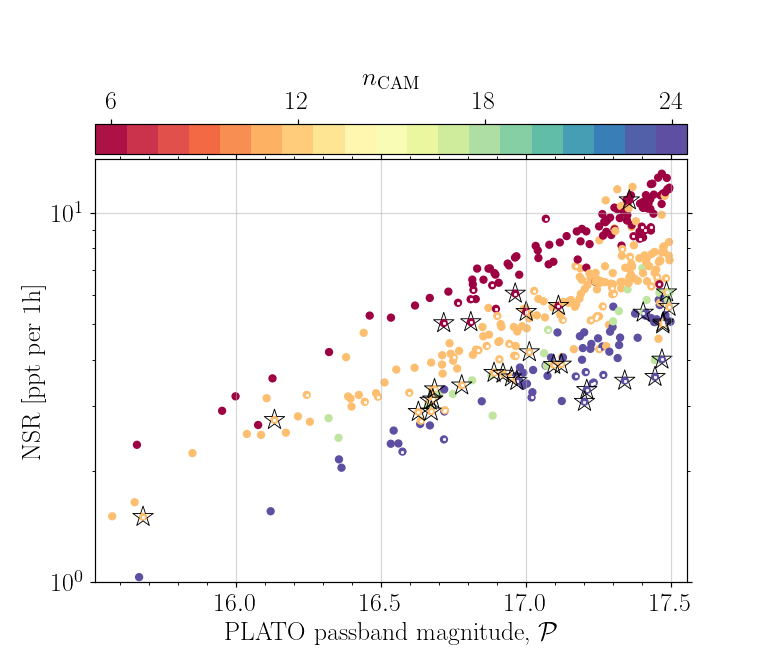

(1.0, 14.0)

In [18]:
# Plot NSR vs. magnitude (show different observing modes)
fig, ax = plt.subplots(1, 1, figsize=(7,6))

# Plot all targets
dx = df0.copy()
mag = dx.Pmag
col = 'ncam'
cmap = 'Spectral'
im0 = ax.scatter(mag, dx.NSR, s=20, alpha=1, zorder=1, c=dx[col], cmap=cmap)

# Plot contaminated targets
dx0 = df1[df1.SPR > 0.01]
ax.scatter(dx0.Pmag, dx0.NSR, s=10, marker='.', facecolors='w', edgecolors='w', lw=0.5)

# Plot targets requested for imagettes
dx1 = df1[(df1.SPR > 0.028) & (df1.SizeDSS < 15)]
ax.scatter(dx1.Pmag, dx1.NSR, s=200, marker='*', facecolors='none', edgecolors='k', lw=0.6)
dx2 = df1[(df1.SPR < 0.028) & (df1.SizeDSS > 15)]
ax.scatter(dx2.Pmag, dx2.NSR, s=200, marker='*', facecolors='none', edgecolors='k', lw=0.6)
# Check objects
# dx3 = df1[(df1.Object == 'Quasar')]
# ax.scatter(dx3.Pmag, dx3.NSR, s=200, marker='s', facecolors='none', edgecolors='k', lw=0.6)
# Identify N-CAM outliers close to edges
# dx3 = df1[(df1.ncam == 12) & (df1.Pmag < 16.5) & (df1.NSR > 3.5)]
# ax.scatter(dx3.Pmag, dx3.NSR, s=200, marker='s', facecolors='none', edgecolors='k', lw=0.6)

# Colorbar
cbins = np.arange(dx[col].min(), dx[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im0, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()

# Settings
ax.set_xlabel('PLATO passband magnitude, $\mathcal{P}$')
ax.set_ylabel('NSR [ppt per 1h]')
dx = (mag.max() - mag.min()) * 0.03
ax.set_xlim(mag.min()-dx, mag.max()+dx)
ax.set_yscale('log')
ax.grid(alpha=0.5)
ax.set_ylim(1e0, 1.4e1)

# Save figure
# fig.savefig(fdir / 'plot_nsr_vs_mag.png', bbox_inches='tight', dpi=300)

In [154]:
# dx = df1[(df1.ncam == 12) & (df1.NSR > 8.4)]
# dx = df1[(df1.ncam == 12) & (df1.Pmag < 16.5) & (df1.NSR > 3.5)]
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True, 
#     raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
#     clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.6, 
#     figsize=(9,9), title='Forbidden sources'
# )

### Plot redshift distribution

In [155]:
# Store data frames
dt = df1.copy()

# Sperate LOPS2 and LOPN1
ds = dt[dt.b < 0]
dn = dt[dt.b > 0]

# Seperate camera visibility
dt06 = dt[dt.ncam ==  6]
dt12 = dt[dt.ncam == 12]
dt18 = dt[dt.ncam == 18]
dt24 = dt[dt.ncam == 24]

# Store global dfs
dt = dt.reset_index(drop=True)

<IPython.core.display.Javascript object>


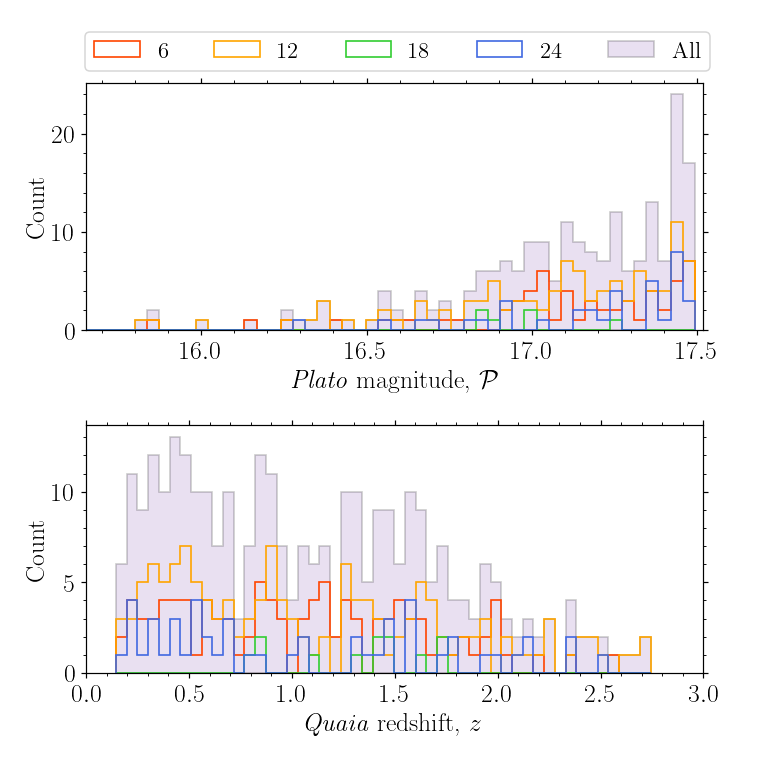

In [156]:
# Plot histograms
aa, lw, N = 0.2, 1.1, 50
c = ['orangered', 'orange', 'limegreen', 'royalblue', 'k']

fig = plt.figure(figsize=(7,7))

ax1 = plt.subplot(2, 1, 1)
G_min, G_max = dt.Pmag.min(), dt.Pmag.max()
ax1.hist(dt06.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dt.Gmag,   bins=N, range=(G_min, G_max), histtype='stepfilled', ec=c[4], lw=lw, alpha=aa, label='All')
ax1.set_xlabel(r'\textit{Plato} magnitude, $\mathcal{P}$')
ax1.set_xlim(G_min, 17.52)
ax1.legend(loc='upper left', bbox_to_anchor=(-0.02, 1.25), ncols=5, fontsize=15)

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = dt.z.min(), dt.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dt.z,   bins=N, range=(z_min, z_max), histtype='stepfilled', ec=c[4], lw=lw, alpha=aa)
ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
ax2.set_xlim(0, 3)

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
#     ax.set_yscale('log')
    ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()
fig.savefig(fdir / 'plot_sample_hists.png', bbox_inches='tight', dpi=300)

### Plot targets in LOPS2 footprint

<IPython.core.display.Javascript object>


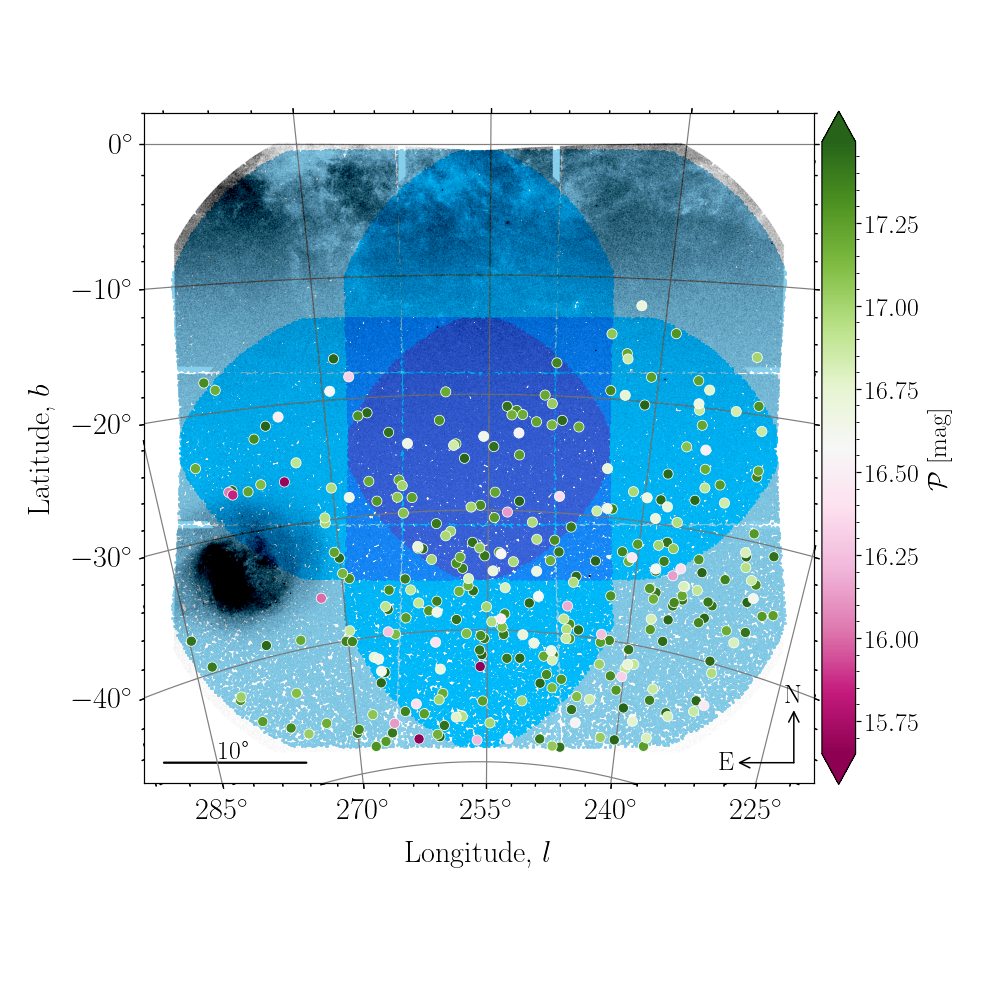

In [157]:
# Plot catalogue within LOPS2 foorptint
dx = df1.sort_values(by='Pmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, showGalactic=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=180, lw=0.5, ec='w',
    clabel=r'$\mathcal{P}$ [mag]', cmap='PiYG', figsize=(9,9)
)
fig.savefig(fdir / 'plot_sample_lops2.png', bbox_inches='tight', dpi=300)